In [1]:
import pandas as pd
df = pd.read_csv("../../data/tableau_features.csv")

In [2]:
from sklearn.model_selection import train_test_split
import os

labels_df = pd.read_csv("../../data/train_data/labels.csv")                

print(f"Features (from laz): {len(df)}")
print(f"Labels (from csv):   {len(labels_df)}")

df['join_id'] = df['filename'].apply(
    lambda x: os.path.splitext(os.path.basename(x))[0]
)

labels_df['join_id'] = labels_df['filename'].apply(
    lambda x: os.path.splitext(os.path.basename(x))[0]
)

full_data = pd.merge(df, labels_df, on='join_id', how='inner')

print(f"Matched Trees: {len(full_data)}")

#juste pour vérifier que les données matchent bien
full_data['height_diff'] = abs(full_data['height'] - full_data['tree_H'])
print(f"Avg Height Diff: {full_data['height_diff'].mean():.2f}m")

clean_data = full_data.copy()
print(f"Trees after cleaning bad matches: {len(clean_data)}")

train_df, val_df = train_test_split(
    clean_data, 
    test_size=0.2, 
    random_state=42, 
    stratify=clean_data['species']
)

cols_to_keep = [
    'crown_ratio','height','crown_ratio','crown_volume', 'crown_area', 'crown_diameter', 'point_density', 'trunk_height', 'p10_height_rel', 'p50_height_rel', 'p90_height_rel',
    'species', 'genus', 'stem_diameter', 'stem_quality', 'is_sapling', 'point_density'
]

Features (from laz): 17707
Labels (from csv):   17707
Matched Trees: 17707
Avg Height Diff: 0.00m
Trees after cleaning bad matches: 17707


In [ ]:


feature_cols = ['crown_ratio','crown_volume', 'crown_area', 'crown_diameter', 'trunk_height', 'p10_height_rel', 'p50_height_rel', 'p90_height_rel',
    'stem_diameter', 'stem_quality', 'is_sapling', 'tree_volume', 'tree_area', 'point_density'
]

Training XGBoost...


c:\Users\mathe\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [08:51:47] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training Complete.
Précision sur les données de validation

Model Accuracy: 62.65%
------------------------------
Classification Report:
                       precision    recall  f1-score   support

           Abies_alba       0.78      0.58      0.67        24
       Acer_campestre       0.41      0.42      0.42       248
  Acer_pseudoplatanus       0.58      0.62      0.60       115
       Acer_saccharum       0.53      0.41      0.46        22
       Betula_pendula       0.64      0.46      0.54       147
     Carpinus_betulus       0.31      0.32      0.32       249
     Corylus_avellana       0.67      0.44      0.53         9
   Crataegus_monogyna       0.44      0.26      0.33        46
   Eucalyptus_miniata       0.81      0.77      0.79        56
   Euonymus_europaeus       0.25      0.14      0.18        21
      Fagus_sylvatica       0.57      0.71      0.63       496
Fraxinus_angustifolia       0.75      0.57      0.65        21
   Fraxinus_excelsior       0.25      0.08 

C:\Users\mathe\AppData\Local\Temp\ipykernel_4104\911167434.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


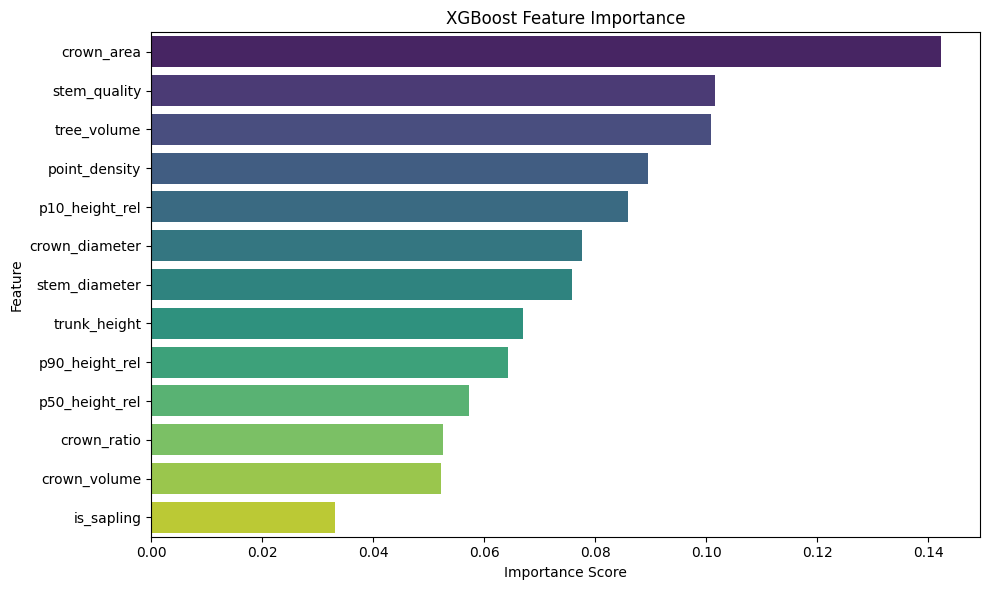

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# 1. Prepare Data
target_col = 'species'

# Ensure feature_cols is defined (assuming you have it from previous steps)
# feature_cols = ['height', 'crown_ratio', 'stem_diameter', 'trunk_height', ...] 

X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_val = val_df[feature_cols]
y_val = val_df[target_col]

# XGBoost requires integer labels (0, 1, 2...)
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_val_encoded = le.transform(y_val)

# 2. Define and Fit XGBoost Model
# use_label_encoder=False removes a warning in newer versions
# eval_metric='mlogloss' prevents another warning for multi-class classification
xgb_model = XGBClassifier(
    n_estimators=2000, 
    learning_rate=0.1,    # Step size shrinkage to prevent overfitting
    max_depth=7,          # Depth of tree (increase if underfitting)
    random_state=42,
    n_jobs=-1,            # Use all CPU cores
    use_label_encoder=False,
    eval_metric='mlogloss'
)

print("Training XGBoost...")
xgb_model.fit(X_train, y_train_encoded)
print("Training Complete.")

# 3. Predict & Evaluate
print("Précision sur les données de validation")
y_pred = xgb_model.predict(X_val)
accuracy = accuracy_score(y_val_encoded, y_pred)

print(f"\nModel Accuracy: {accuracy:.2%}")
print("-" * 30)
print("Classification Report:")
print(classification_report(y_val_encoded, y_pred, target_names=le.classes_))

# 5. Feature Importance Plot
importances = xgb_model.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': feature_cols, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('XGBoost Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [9]:
print("Précision sur les données d'entrainement")
y_pred_train = xgb_model.predict(X_train)
accuracy_train = accuracy_score(y_train_encoded, y_pred_train)

print(f"\nModel Accuracy: {accuracy_train:.2%}")
print("-" * 30)
print("Classification Report:")
print(classification_report(y_train_encoded, y_pred_train, target_names=le.classes_))

Précision sur les données d'entrainement

Model Accuracy: 100.00%
------------------------------
Classification Report:
                       precision    recall  f1-score   support

           Abies_alba       1.00      1.00      1.00        95
       Acer_campestre       1.00      1.00      1.00       992
  Acer_pseudoplatanus       1.00      1.00      1.00       461
       Acer_saccharum       1.00      1.00      1.00        88
       Betula_pendula       1.00      1.00      1.00       588
     Carpinus_betulus       1.00      1.00      1.00       994
     Corylus_avellana       1.00      1.00      1.00        39
   Crataegus_monogyna       1.00      1.00      1.00       183
   Eucalyptus_miniata       1.00      1.00      1.00       224
   Euonymus_europaeus       1.00      1.00      1.00        83
      Fagus_sylvatica       1.00      1.00      1.00      1986
Fraxinus_angustifolia       1.00      1.00      1.00        86
   Fraxinus_excelsior       1.00      1.00      1.00       1

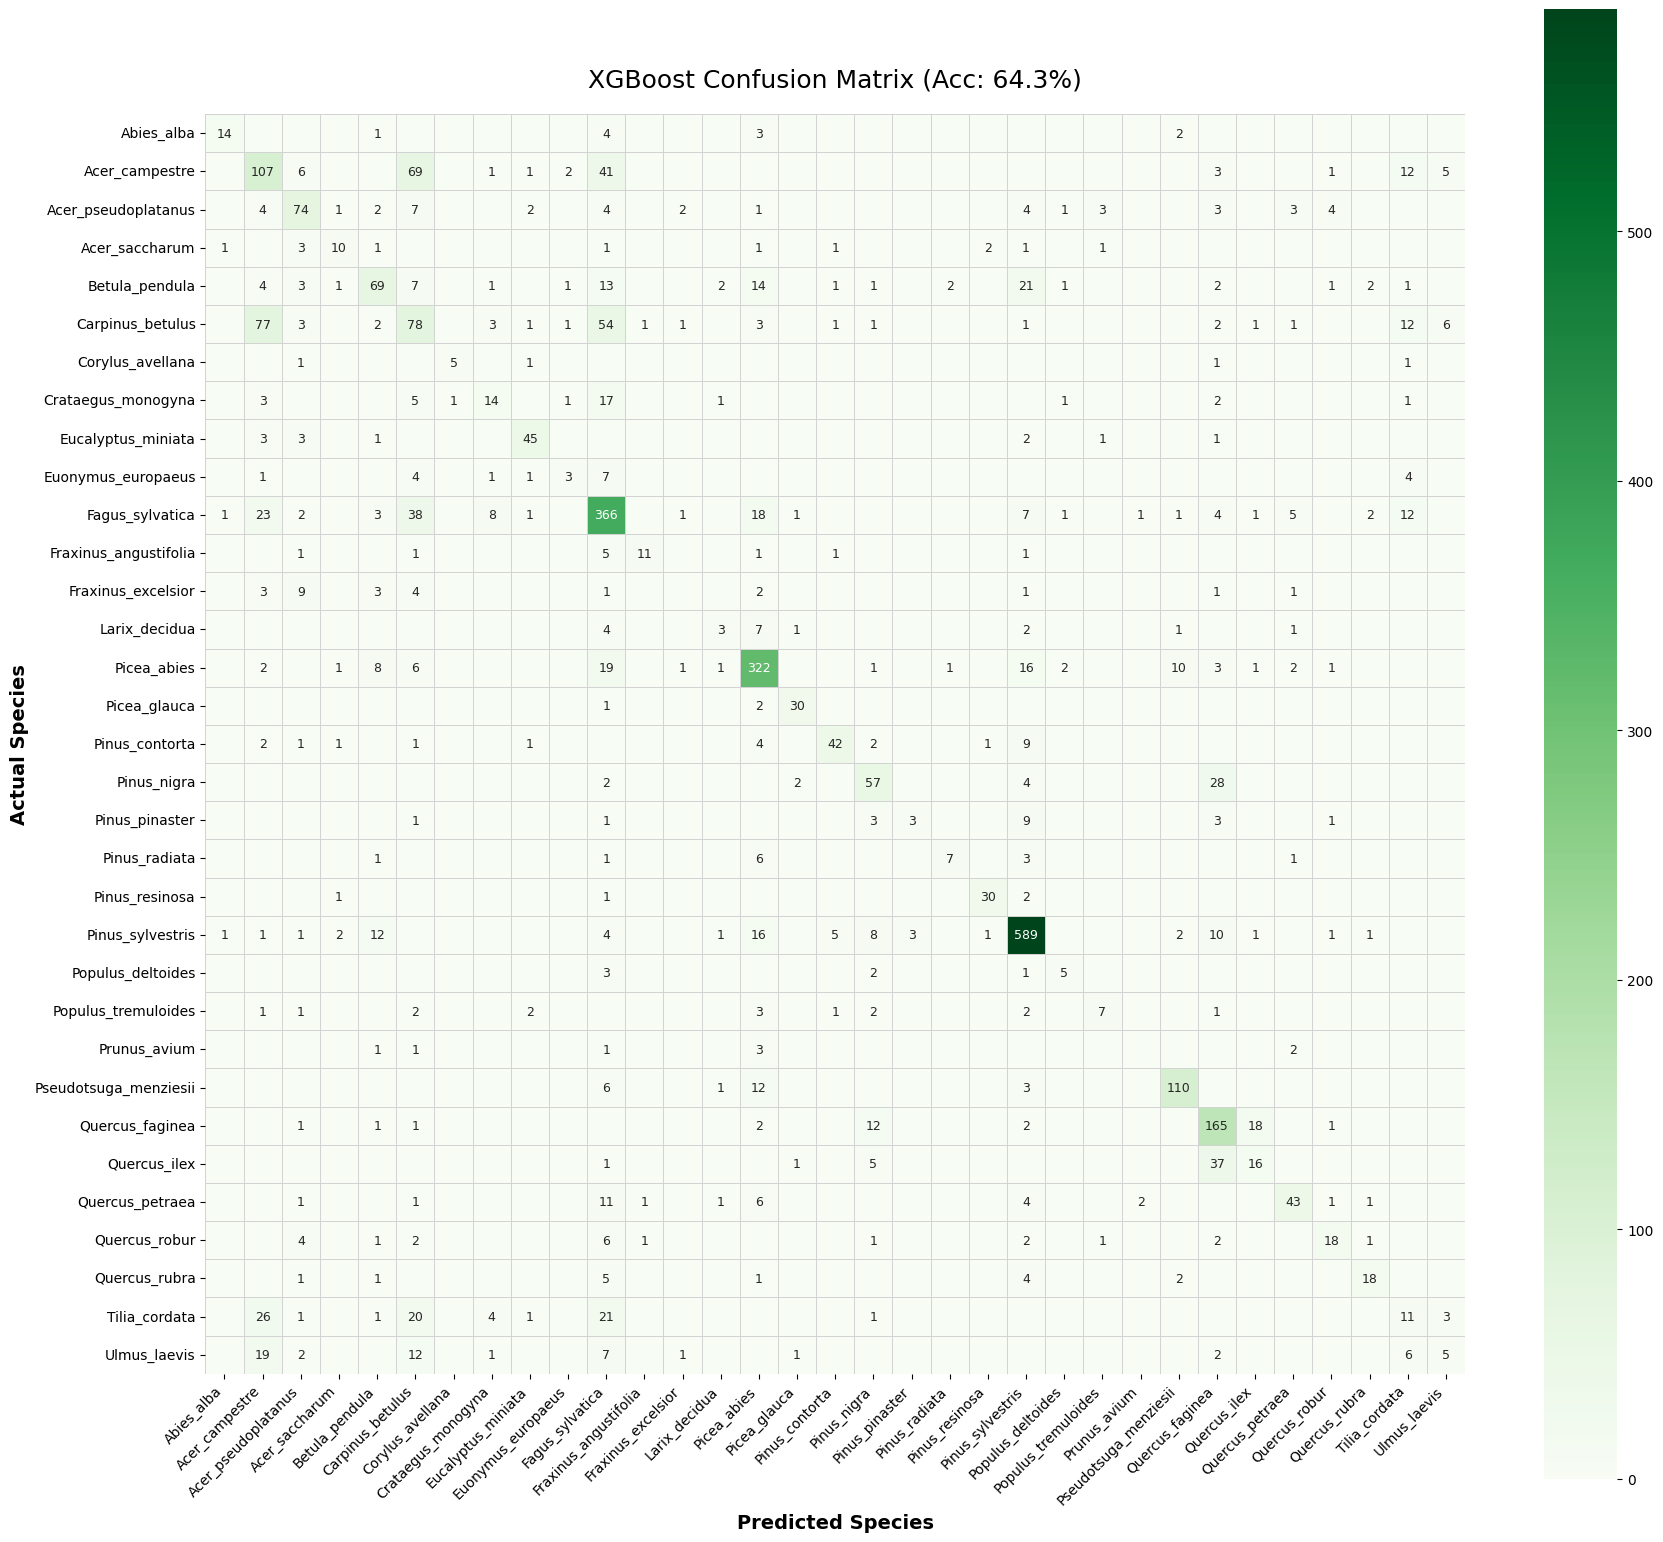

In [5]:
# 4. "Pretty" Confusion Matrix (Cleaned Up)
cm = confusion_matrix(y_val_encoded, y_pred)

# Create annotations: Only add text if the count is greater than 0
# This removes the "0 (0.0%)" clutter from the empty cells
annot_labels = []
for count in cm.flatten():
    if count == 0:
        annot_labels.append("")  # Leave zero cells entirely blank
    else:
        annot_labels.append(f"{count}") # Only display the raw count

annot_labels = np.asarray(annot_labels).reshape(cm.shape)

# Increase the figure size to give the 30+ classes more breathing room
plt.figure(figsize=(18, 16)) 

sns.heatmap(
    cm, 
    annot=annot_labels, 
    fmt='', 
    cmap='Greens', 
    xticklabels=le.classes_, 
    yticklabels=le.classes_,
    linewidths=0.5, 
    linecolor='lightgray',
    cbar=True,              # Turned the colorbar ON so readers can gauge density visually
    square=True,
    annot_kws={"size": 9}   # Shrunk the font size inside the boxes
)

plt.xlabel('Predicted Species', fontsize=14, fontweight='bold')
plt.ylabel('Actual Species', fontsize=14, fontweight='bold')
plt.title(f'XGBoost Confusion Matrix (Acc: {accuracy:.1%})', fontsize=18, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10) # Angled ticks, slightly smaller font
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

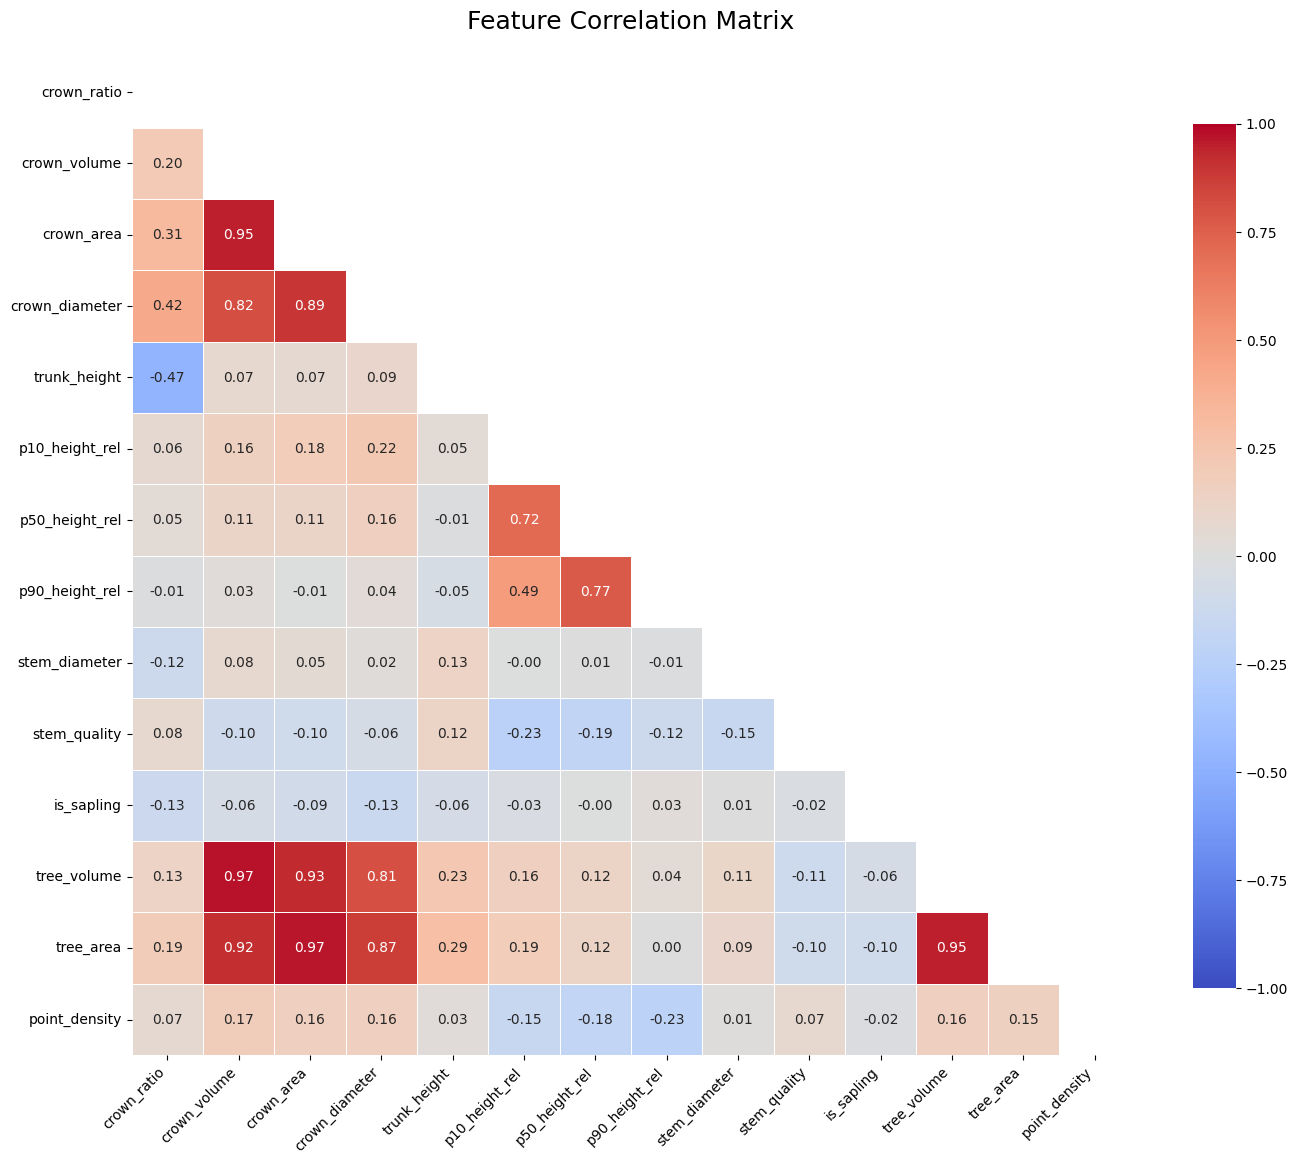

In [12]:
# Calculate the correlation matrix for the features
corr_matrix = train_df[feature_cols].corr()

# Create a mask to hide the upper triangle (removes duplicate/redundant info)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Set up the matplotlib figure
plt.figure(figsize=(14, 12))

# Draw the heatmap
sns.heatmap(
    corr_matrix, 
    mask=mask,               # Apply the mask here
    cmap='coolwarm',         # A good diverging colormap for correlations (blue = negative, red = positive)
    vmin=-1, vmax=1,         # Anchor the color scale from -1 to 1
    annot=True,              # Show the correlation values
    fmt=".2f",               # Limit to 2 decimal places to avoid clutter
    linewidths=0.5, 
    linecolor='white',
    cbar_kws={"shrink": .8}, # Slightly shrink the colorbar
    square=True,
    annot_kws={"size": 10}   # Adjust font size for the numbers
)

plt.title('Feature Correlation Matrix', fontsize=18, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

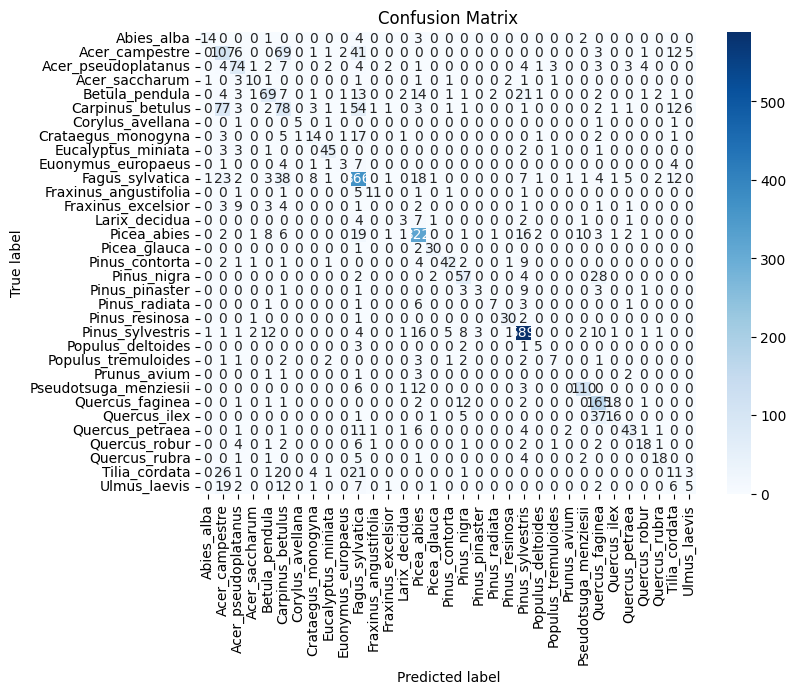

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix (if not already computed)
cm = confusion_matrix(y_val_encoded, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix')
plt.show()

In [8]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# 1. Setup
X = train_df[feature_cols]
y = y_train_encoded

# 2. Define the "Selector"
# n_features_to_select=5 means "Keep only the top 5 best features"
rf = RandomForestClassifier(n_estimators=50, random_state=42)
rfe = RFE(estimator=rf, n_features_to_select=8)

# 3. Fit (This takes a moment, it trains the model multiple times)
print("Finding the best features...")
rfe.fit(X, y)

# 4. See results
ranking = pd.DataFrame({'Feature': feature_cols, 'Rank': rfe.ranking_, 'Keep': rfe.support_})
print(ranking.sort_values(by='Rank'))

Finding the best features...
           Feature  Rank   Keep
1           height     1   True
7   p50_height_rel     1   True
6   p10_height_rel     1   True
4   crown_diameter     1   True
13       tree_area     1   True
14   point_density     1   True
10    stem_quality     1   True
8   p90_height_rel     1   True
9    stem_diameter     2  False
12     tree_volume     3  False
3       crown_area     4  False
0      crown_ratio     5  False
2     crown_volume     6  False
5     trunk_height     7  False
11      is_sapling     8  False
